# 07 · UMAP

PCA gave you straight axes you could read off as loadings. UMAP gives you a picture —
more legible, and much easier to over-read.

| | |
|---|---|
| **1** | Choose the features, and build the graph |
| **2** | Run UMAP |
| **3** | Colour it by everything you know |
| **4** | What UMAP does *not* preserve |
| **5** | What the picture actually says |
| **6** | Save the embedding |

:::{note}
These are the **controls** — every DMSO and PBS cell, and nothing else. Neither is a
treatment, so a UMAP of them should show the cells arranging themselves by time and by
state, and should show nothing at all about which of the two they came from. Section 5
checks whether it does, with numbers rather than by eye.
:::

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def panel_grid(n, *, ncols=3, size=(3.6, 3.0)):
    """A figure with `n` axes on a grid, the unused ones removed."""
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, squeeze=False,
                             figsize=(size[0] * ncols, size[1] * nrows))
    flat = axes.ravel()
    for ax in flat[n:]:
        ax.remove()
    return fig, flat[:n]
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/data_mcs_2026")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
print(f"{cells.n_obs:,} cells x {cells.n_vars} markers")
print(f"  conditions: {sorted(cells.obs.condition.astype(str).unique())}, "
      f"{cells.obs.well.nunique()} wells")
print(f"  obsm: {list(cells.obsm)}")

97,177 cells x 38 markers
  conditions: ['DMSO', 'PBS'], 32 wells
  obsm: ['X_pca']


## 1 · Choose the features, and build the graph

UMAP does not work on the cells directly. It works on a **graph** — each cell joined to
its nearest neighbours — and the embedding is an attempt to draw that graph on a page.
Everything you can change about a UMAP, you change here, and the first thing to change is
**which numbers decide who is a neighbour**.

[Chapter 06](06_pca.ipynb) surveyed all 38 markers and found the largest axis of variation
was how brightly a cell stained. That is the right answer to the question it asked and the
wrong basis for this one: a cell's *identity* should not depend on how bright its
lysosomes are.

So cut to the markers that define identity — eight transcription factors and one receptor,
each marking a lineage a naive human embryonic stem cell can become:

| markers | lineage |
|---|---|
| Oct4, Nanog, Sox2 | **pluripotent** — the starting state |
| GATA3 | **trophectoderm** |
| GATA4, GATA6, SOX17, PDGFRa | **hypoblast** (primitive endoderm) |

In [2]:
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]
cells.obsm["X_identity"] = np.asarray(cells[:, identity].X)
cells.var.loc[identity, ["marker", "round", "channel", "species", "failed"]]

,marker,round,channel,species,failed
Oct4,Oct4,1,Texas Red,Mouse,False
Nanog,Nanog,1,FITC,Goat,False
Sox2,Sox2,3,Cy5,Rat,False
GATA3,GATA3,14,FITC,Rabbit,False
GATA6,GATA6,2,Texas Red,Mouse,False
PDGFRa,PDGFRa,18,FITC,Goat,False
GATA4,GATA4,2,Cy5,Rat,False
SOX17,SOX17,4,FITC,Goat,False


:::{note}
**Look at the PDGFRa row.** It was stained twice — round 0 in Cy5, which is one of the two
stains [Step 9](../1_preparation/01_columns_to_markers.ipynb) marked `failed`, and round 18
in FITC, which passed. `resolve_panel` takes the round-18 column because it reads the
`failed` flag; asking for "the PDGFRa column" by name would have taken whichever came
first, and that is the dead one.

This is the payoff of Steps 7 and 9 in a single line. The decoder is not bookkeeping.
:::

In [3]:
sc.pp.neighbors(cells, n_neighbors=15, use_rep="X_identity", random_state=0)
print(f"  graph: {cells.obsp['connectivities'].shape[0]:,} cells, "
      f"{cells.obsp['connectivities'].nnz:,} edges")
print(f"  obsp: {list(cells.obsp)}")

/cluster/home/maaraujo/venvs/mcs2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  graph: 97,177 cells, 1,885,118 edges
  obsp: ['distances', 'connectivities']


`n_neighbors` is the one parameter that changes the picture most. Small values emphasise
local structure and fragment the map; large values smooth it into continents. There is no
correct value — Exercise 1 asks you to look at three.

The graph lands in `obsp`, the slot for cell × cell matrices. It is sparse, and it is what
chapters 08, 09 and 10 all reuse — clusters, an abstracted graph and a diffusion map are
three different questions asked of this one object.

### Was cutting to eight a good idea?

It is a claim, so test it. Build the *other* graph — the one from chapter 06's PCA of all
38 markers — and ask both the same question: how often does a cell's neighbour share its
label, against how often it would by chance?

The labels split into two kinds. **Timepoint** is real biology and a good graph should find
it. **Well** and **plate row** are batch: nothing was done differently to these wells, so
any structure there is the assay, not the cells.

The measure is short enough to read, and worth reading: two details in it are what make
the answer trustworthy, and both are easy to get wrong.

**Self-pairs must not count.** scanpy stores each cell as its own neighbour in `distances`,
so a cell would always "share its label with itself" and every ratio would drift toward 1.

**`within` and `exclude` ask different questions.** `within` compares only inside a block and
recomputes chance there. `exclude` throws away pairs that share a *nested* label — which is
how you tell a real plate-row effect from the well effect wearing a row's clothes.

In [4]:
def neighbour_purity(data, labels, *, within=None, exclude=None, neighbors_key=None):
    """How often a cell's neighbours share its label, against chance.

    `within` restricts every comparison to cells in the same block, so chance is
    recomputed inside each block. `exclude` drops pairs that share a nested
    label -- pass the well when asking about the plate row, or the row effect you
    measure is really the well effect wearing a row's clothes.

    Self-pairs never count. scanpy stores each cell as its own neighbour in
    `distances` on real data and not on small synthetic data; left in, every
    ratio drifts toward 1. With no `exclude`, each cell is its own group, so
    "different group" already means "not itself".
    """
    key = data.uns[neighbors_key or "neighbors"]["distances_key"]
    graph = data.obsp[key]
    labels = np.asarray(labels)
    n = len(labels)
    blocks = np.asarray(within) if within is not None else np.zeros(n, int)
    groups = np.asarray(exclude) if exclude is not None else np.arange(n)

    rows = np.repeat(np.arange(n), np.diff(graph.indptr))     # every stored edge
    cols = graph.indices
    keep = (blocks[rows] == blocks[cols]) & (groups[rows] != groups[cols])
    same = int((labels[rows[keep]] == labels[cols[keep]]).sum())
    pairs = int(keep.sum())

    # Chance, as a count of eligible pairs: draw two cells from one block, reject
    # them if `exclude` groups them together, ask how often the labels match.
    matching = eligible = 0.0
    frame = pd.DataFrame({"block": blocks, "label": labels, "group": groups})
    for _, chunk in frame.groupby("block", observed=True):
        by_label = chunk.groupby("label", observed=True).size()
        by_group = chunk.groupby("group", observed=True).size()
        by_both = chunk.groupby(["label", "group"], observed=True).size()
        matching += float((by_label ** 2).sum() - (by_both ** 2).sum())
        eligible += float(len(chunk) ** 2 - (by_group ** 2).sum())
    expected = matching / eligible if eligible else float("nan")
    return {"observed": same / pairs if pairs else float("nan"),
            "expected": expected,
            "ratio": (same / pairs) / expected if pairs and expected else float("nan"),
            "pairs": pairs}

In [5]:
alternative = cells.copy()
sc.pp.pca(alternative, n_comps=20, random_state=0)
sc.pp.neighbors(alternative, n_neighbors=15, n_pcs=15, random_state=0)

block = (cells.obs.condition.astype(str) + "_" + cells.obs.timepoint_h.astype(str)).values
labels = {
    "timepoint — real": (cells.obs.timepoint_h.astype(int), {}),
    "condition — should be nothing": (cells.obs.condition.astype(str), {}),
    "well": (cells.obs.well.astype(str), {}),
    "well, within condition × timepoint": (cells.obs.well.astype(str), {"within": block}),
    "plate row": (cells.obs.row.astype(str), {}),
}
comparison = pd.DataFrame({
    "all 38, via PCA": {name: neighbour_purity(alternative, v, **kw)["ratio"]
                        for name, (v, kw) in labels.items()},
    "the 8 identity markers": {name: neighbour_purity(cells, v, **kw)["ratio"]
                               for name, (v, kw) in labels.items()},
}).round(2)
comparison.index.name = "neighbours share their…"
comparison

,"all 38, via PCA",the 8 identity markers
neighbours share their…,,
timepoint — real,2.53,1.76
condition — should be nothing,1.21,1.07
well,8.60,3.54
"well, within condition × timepoint",2.71,1.82
plate row,2.63,1.55


:::{important}
**The cut halves the batch effect and leaves the biology exactly where it was.**

Timepoint purity is *identical* on both graphs — the differentiation signal does not care
which of the two feature sets you used. But cells from the same well neighbour each other
far less often once the other thirty markers are gone, and the same is true of plate row.

The thirty markers you dropped were not carrying identity. They were carrying **well-to-
well staining variation**, which every marker has a little of, and which thirty of them
add up to. Choosing eight did not discard information so much as decline to average in
thirty copies of the assay's noise.

That is the general argument for a panel, and it is worth more than the specific numbers:
**a feature you include for completeness still votes.** If it has nothing to say about
your question, what it votes with is its noise.
:::

## 2 · Run UMAP

In [6]:
sc.tl.umap(cells, random_state=0)
coords = cells.obsm["X_umap"]
print(f"  embedded {coords.shape[0]:,} cells into {coords.shape[1]} dimensions")
print(f"  obsm: {list(cells.obsm)}")

  embedded 97,177 cells into 2 dimensions
  obsm: ['X_pca', 'X_identity', 'X_umap']


## 3 · Colour it by everything you know

A UMAP on its own tells you nothing at all. It becomes evidence only when coloured by a
variable you did **not** use to build it — and the graph above was built from markers
only, so every column of `obs` qualifies.

The quickest way is scanpy's own plotter, which takes anything in `obs` or any marker
name and handles the legend for you.

`vmin`/`vmax` are not decoration. Intensities have long tails — one cell 30 SDs above the
control will take the whole colour bar and leave every other cell the same shade of dark
blue. Clipping to the 2nd and 98th percentiles shows the structure instead of the
outlier, and you say so in the caption.

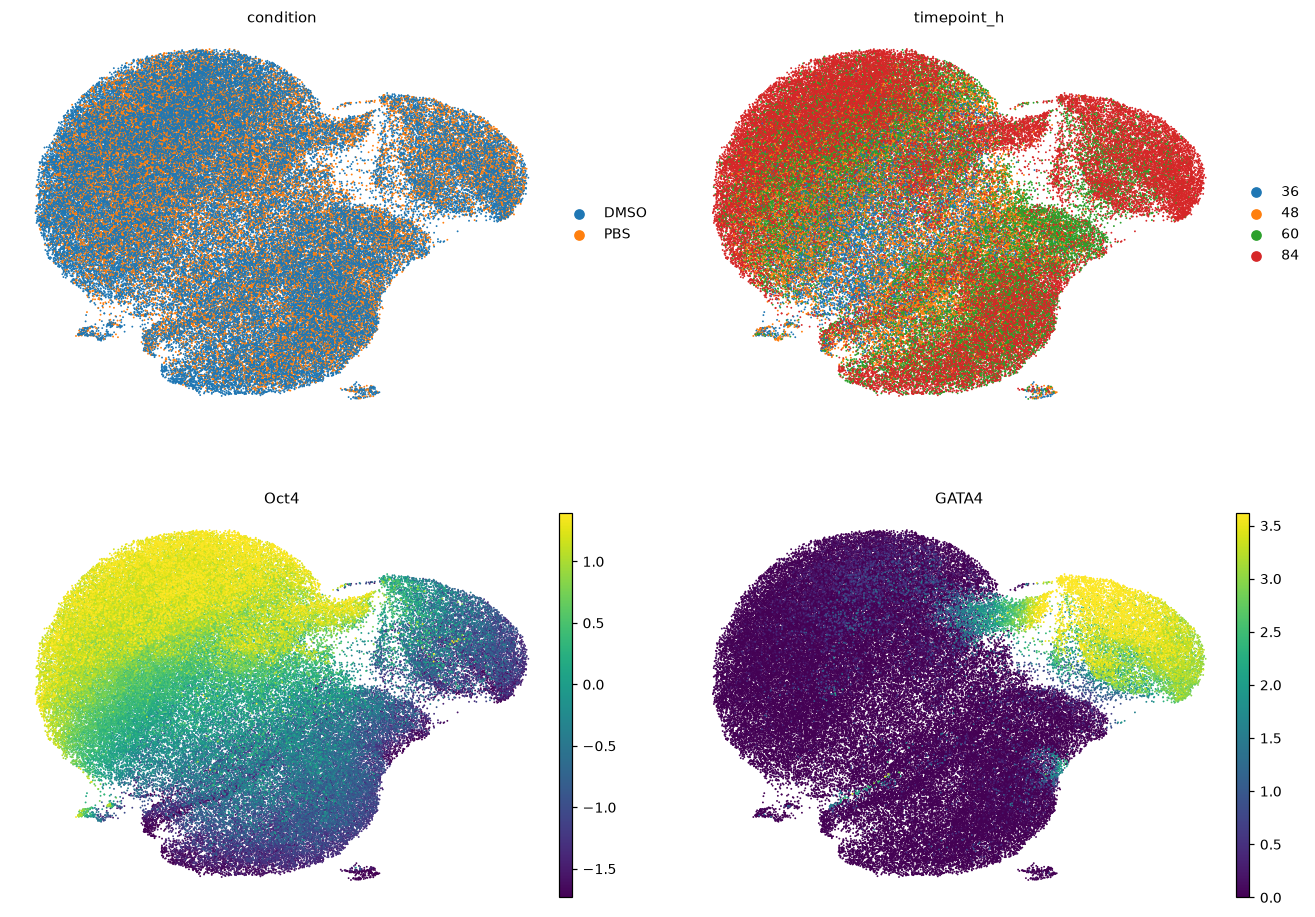

In [7]:
sc.pl.umap(cells, color=["condition", "timepoint_h", "Oct4", "GATA4"],
           ncols=2, s=6, frameon=False, cmap="viridis", vmin="p2", vmax="p98")

Four panels, and they divide into two pairs.

| coloured by | should it show structure? |
|---|---|
| `condition` — DMSO against PBS | **no.** Neither is a treatment |
| `timepoint_h` | **yes.** Two days of differentiation is real |
| `Oct4` | **yes.** Pluripotent cells are a real population |
| `GATA4` | **yes**, and somewhere else — that is the state they become |

Read the first panel against the other three. A method that separated the two controls
while also separating time and lineage would be telling you it is sensitive; a method
that separates *only* the controls would be telling you it is broken. Section 5 puts a
number on which of those happened.

### The same thing by hand

`sc.pl.umap` is convenient and inflexible. Once you want two conditions picked out
against a grey background, or a colour bar clipped to a range, draw it yourself — it is
a scatter plot of two columns.

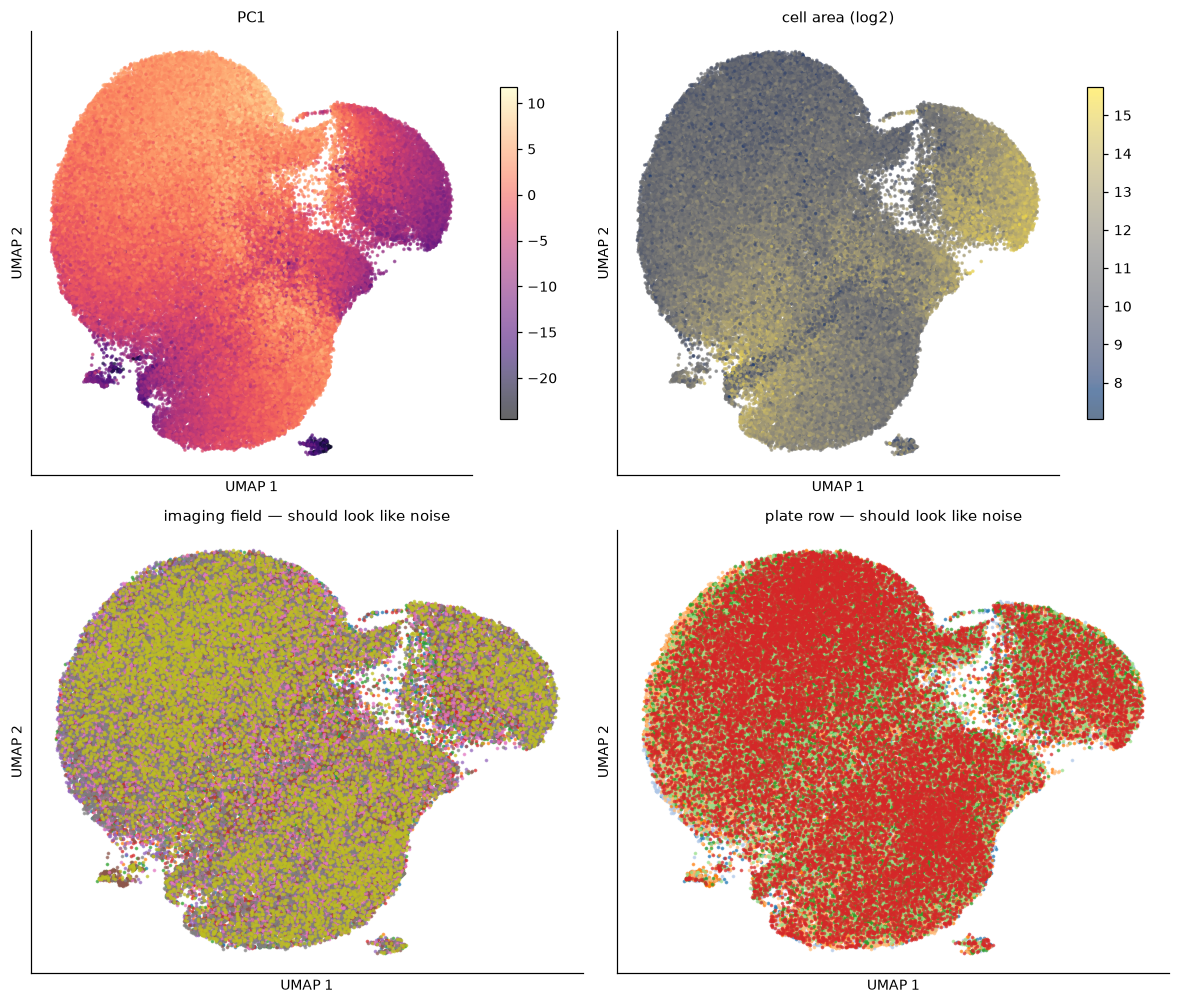

In [8]:
fig, axes = panel_grid(4, ncols=2, size=(5.4, 4.6))

s = axes[0].scatter(coords[:, 0], coords[:, 1], c=cells.obsm["X_pca"][:, 0],
                    cmap="magma", s=2, alpha=0.6)
axes[0].set_title("PC1"); fig.colorbar(s, ax=axes[0], shrink=0.75)

s = axes[1].scatter(coords[:, 0], coords[:, 1], c=np.log2(cells.obs.area),
                    cmap="cividis", s=2, alpha=0.6)
axes[1].set_title("cell area (log2)"); fig.colorbar(s, ax=axes[1], shrink=0.75)

fields = cells.obs.ROI.astype(str)
for value, colour in zip(sorted(fields.unique()), plt.cm.tab10.colors):
    mask = (fields == value).values
    axes[2].scatter(coords[mask, 0], coords[mask, 1], s=2, alpha=0.6, color=colour)
axes[2].set_title("imaging field — should look like noise")

rows = cells.obs.row.astype(str)
for value, colour in zip(sorted(rows.unique()), plt.cm.tab20.colors):
    mask = (rows == value).values
    axes[3].scatter(coords[mask, 0], coords[mask, 1], s=2, alpha=0.6, color=colour)
axes[3].set_title("plate row — should look like noise")

for ax in axes:
    ax.set(xticks=[], yticks=[], xlabel="UMAP 1", ylabel="UMAP 2")
fig.tight_layout()

The last panel is a control, and worth making a habit. **Plate row is not biology.** If
the map separates by row, or by well, or by imaging field, you are looking at a batch
effect and everything else on the picture is suspect.

## 4 · What UMAP does *not* preserve

Three things people read off UMAPs that are not there:

**Distance between clusters is not meaningful.** Two blobs far apart are not "more
different" than two blobs close together. UMAP optimises local neighbourhoods and lets
global geometry fall where it may.

**Cluster size is not meaningful.** A dense island can hold fewer cells than a sparse
smear. Area on the page reflects the embedding's local scaling, not cell counts.

**The shape is not stable.** Change the seed or `n_neighbors` and the picture rearranges
while the underlying data has not moved.

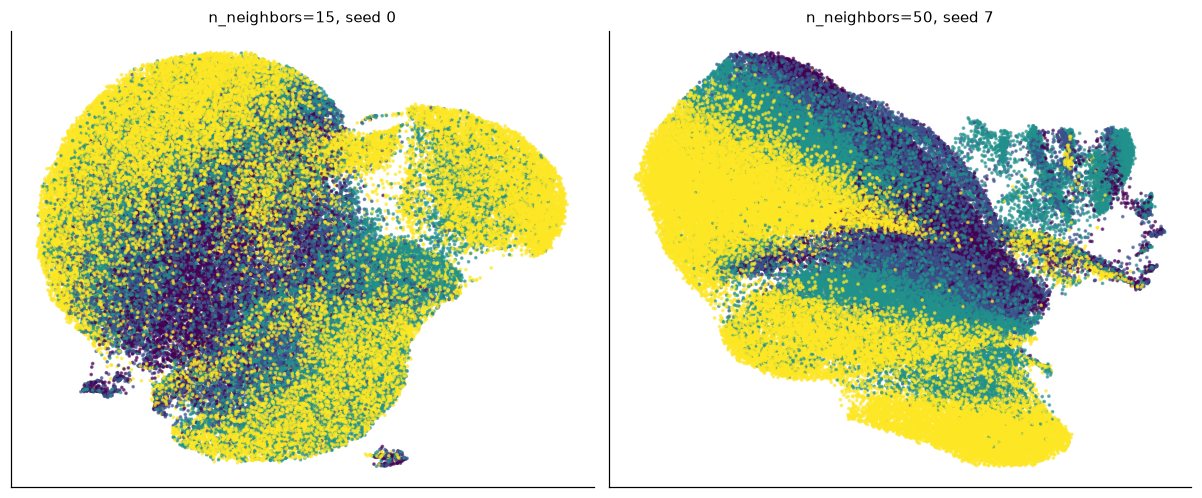

In [9]:
alt = cells.copy()
sc.pp.neighbors(alt, n_neighbors=50, n_pcs=15, use_rep="X_pca", random_state=0)
sc.tl.umap(alt, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (xy, label) in zip(axes, [(coords, "n_neighbors=15, seed 0"),
                                  (alt.obsm["X_umap"], "n_neighbors=50, seed 7")]):
    ax.scatter(xy[:, 0], xy[:, 1], c=cells.obs.timepoint_h.astype(int), cmap="viridis",
               s=2, alpha=0.6)
    ax.set(title=label, xticks=[], yticks=[])
fig.tight_layout()

:::{warning}
**Same cells, same PCA, two different pictures.** Anything you can say about one and not
the other is a statement about UMAP, not about the biology.

Use a UMAP to *notice* things — a group that separates, a gradient worth chasing. Then
go and test the claim with numbers, at the well level.
:::

### What it does preserve, for once: the population

Every earlier warning in this section is about the method. This one is about the data, and
it goes the other way: these are **all** the control cells, not a sample of them. No
subsampling, no sketch, nothing over- or under-represented.

That is unusual and worth noticing, because it is what lets you read a density on this
page as a real density. It stops being true the moment you leave the controls — 653,000
cells will not go through a neighbour graph, so
[Part 4](../../part4_final_solutions/intro.md) embeds a *sketch* of the plate and cannot
count anything on it.

## 5 · What the picture actually says

[Section 1](#choose-the-features-and-build-the-graph) already put a number on the map: the
two controls are interleaved (1.05× chance), timepoint is real (1.91×), and cells from one
well sit together more often than they should. This section finishes that last one, because
it is the finding that changes how you work — and because the first table overstated it.

One thing to know before reading any of it.

In [10]:
pd.crosstab(cells.obs.condition.astype(str), cells.obs.row.astype(str))

row,B,D,H,I,L,M,O
condition,,,,,,,
DMSO,0,12402,14219,14244,0,0,22020
PBS,9289,0,0,0,13192,11811,0


:::{warning}
**The two controls do not share a single plate row.** Condition and row are perfectly
confounded here, so a difference between DMSO and PBS could equally be a difference between
the top and the bottom of the plate, and no analysis can separate them.

That is a fact about how the plate was laid out, not about the code. It belongs *before*
the result rather than after it — it changes what a positive result would mean, and it
raises the value of a negative one.
:::

### These labels nest, and a nested label borrows signal

Both of the batch numbers are inflated, for the same reason. Every **well** has exactly one
timepoint, so part of the well signal is the timepoint signal wearing a different name. And
every **row** is a bag of wells, so part of the row signal is the well signal.

Two arguments strip each of those out. `within` counts only pairs from the same block —
use it to separate a label from what it sits *inside*:

In [11]:
block = (cells.obs.condition.astype(str) + "_"
         + cells.obs.timepoint_h.astype(str)).values

pd.DataFrame({
    "well, all pairs": neighbour_purity(cells, cells.obs.well.astype(str)),
    "well, within condition × timepoint":
        neighbour_purity(cells, cells.obs.well.astype(str), within=block),
}).T[["observed", "expected", "ratio", "pairs"]].round(3)

,observed,expected,ratio,pairs
"well, all pairs",0.145,0.041,3.541,1457655.0
"well, within condition × timepoint",0.428,0.236,1.818,493260.0


`exclude` counts only pairs from *different* groups — use it to separate a label from what
sits inside **it**. Do the cells of one plate row group together at all, once you stop
counting cells that share a well?

In [12]:
pd.DataFrame({
    "row, all pairs": neighbour_purity(cells, cells.obs.row.astype(str)),
    "row, ignoring same-well pairs":
        neighbour_purity(cells, cells.obs.row.astype(str),
                                  within=block, exclude=cells.obs.well.astype(str)),
}).T[["observed", "expected", "ratio", "pairs"]].round(3)

,observed,expected,ratio,pairs
"row, all pairs",0.237,0.153,1.551,1457655.0
"row, ignoring same-well pairs",0.059,0.061,0.964,281989.0


:::{important}
**Two findings, pointing in opposite directions.**

**There is no plate-position effect.** Once same-well pairs are excluded, the row ratio
lands within a few per cent of 1 — observed and expected agree to two decimals. The
apparent row structure
was entirely inherited from the wells inside it. That also settles the confound flagged
above: rows carry no signal of their own, so DMSO and PBS sitting on different rows costs
nothing.

**The well effect is real, and survives every control.** Cells from the same well still sit
together more often than chance *within a single condition and timepoint*, in two groups
that received no treatment at all. Nothing was done to these wells that was not done to the
others. What they share is a drop of medium, a position, a local cell density and one
imaging session — and that is enough.

Note how far the number fell: about 2.2 on the 38-feature graph, and much less than that
here. Both are above 1, so the conclusion is the same — but the size of a batch effect is a
property of **the features you chose**, not of the plate alone. Quote it with the feature
set it came from.

This is the replicate-unit argument arriving as a measurement rather than an assertion.
Cells within a well are **not** independent, and this is how far from independent they are.
:::

### One contradiction worth holding on to

The cells do not separate. Do the **wells**?

In [13]:
wells = (cells.to_df()
         .groupby([cells.obs.condition.astype(str), cells.obs.timepoint_h.astype(int),
                   cells.obs.well.astype(str)], observed=True).mean()
         .rename_axis(["condition", "timepoint", "well"]).reset_index())
names = [c for c in wells.columns if c not in ("condition", "timepoint", "well")]
difference = (wells[wells.condition == "PBS"][names].mean()
              - wells[wells.condition == "DMSO"][names].mean())

print(f"  markers shifted by more than 1 control SD: {(difference.abs() > 1).sum()} of {len(names)}")
print(f"  median |shift|: {difference.abs().median():.2f} control SDs")
difference.reindex(difference.abs().sort_values(ascending=False).index).head(5).round(2)

  markers shifted by more than 1 control SD: 0 of 38
  median |shift|: 0.07 control SDs


a-Tubulin       0.24
GRP78           0.21
p-MyosinIIa     0.20
PDGFRa          0.19
Mitochondria    0.18
dtype: float32

So PBS and DMSO are **not** the same — several markers differ by well over a control
standard deviation, and the largest by nearly two.

Both results are true at once, and the reason is worth internalising: a shift of two
control-well SDs is small next to the spread of single cells *within* a well. The
distributions overlap almost entirely, so no embedding or clustering will ever split them,
while a well-level comparison sees the shift immediately.

**An embedding is not a detector.** "The groups do not separate on the UMAP" is not
evidence that they are the same, and never was.

## 6 · Save the embedding

`obsm["X_umap"]` and the graph in `obsp` both travel with the object. Chapters 08 and 09
reuse them rather than recomputing.

In [14]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obsm : {list(cells.obsm)}")
print(f"  obsp : {list(cells.obsp)}")
print(f"  uns  : {sorted(cells.uns)}")

  obsm : ['X_pca', 'X_identity', 'X_umap']
  obsp : ['distances', 'connectivities']
  uns  : ['condition_colors', 'decode_report', 'dropped_wells', 'neighbors', 'panels', 'pca', 'provenance', 'subset_conditions', 'subset_of', 'subset_reason', 'themes', 'timepoint_h_colors', 'umap']


---

## Exercises

### 1. How much does `n_neighbors` change your reading?

Run UMAP at `n_neighbors` = 5, 15 and 50, holding the seed fixed. Which features of the
picture survive all three?

:::{admonition} Solution
:class: dropdown

Small values shatter the map into many small islands; large values merge everything into
a few continents. What tends to survive is the *ordering* — if timepoints lie along a
gradient at 15, they usually still do at 50.

A practical rule: only report structure that is stable across at least two settings, and
say which you used.
:::

### 2. Does the whole plate look like this?

Embed a geosketch of all eighteen conditions — `mcs2026_sketch.h5ad` — the same way, and
put the two maps side by side. What is present in one and not the other?

:::{admonition} Solution
:class: dropdown

```python
plate = sc.read_h5ad(DATA / "mcs2026_sketch.h5ad")
sc.pp.pca(plate, n_comps=20, random_state=0)
sc.pp.neighbors(plate, n_neighbors=15, n_pcs=15, random_state=0)
sc.tl.umap(plate, random_state=0)
sc.pl.umap(plate, color=["timepoint_h", "Oct4"], s=6, frameon=False)
```

The broad arrangement survives — time and pluripotency organise both maps — which is the
reassuring part: the controls are not a strange corner of the dataset.

What the plate map adds is regions the controls never reach, because sixteen of its
eighteen conditions were chosen to push the cells somewhere. Naming those regions is
Part 4's job, and doing it before you have run the methods here is how you end up
describing an artefact with confidence.
:::

### 3. Colour it by something that should mean nothing

Colour the map by `ROI` (the imaging field within a well) and by `label` (the
segmentation index). What would it mean if either of them showed structure?

:::{admonition} Solution
:class: dropdown

Both should look like noise. `ROI` showing structure would mean position within the well
affects the measurement — an illumination or focus artefact. `label` showing structure
would be stranger still, since it is only an ordering assigned by the segmentation, and
would point at something systematic in how objects were numbered.

Negative controls like these cost one line each and are the cheapest protection against
reporting an artefact.
:::

---

**Next:** [08 · Cell-type annotation](08_cell_type_annotation.ipynb).